# Виявлення дублікатів питань Quora

## 1. Імпорт бібліотек

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
import string
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.metrics import classification_report, confusion_matrix
import lightgbm as lgb
from transformers import BertTokenizer, BertModel
import torch
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from sklearn.model_selection import GridSearchCV
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import joblib
import os

## 2. Завантаження даних

In [2]:
df = pd.read_csv('quora_question_pairs_train.csv.zip',index_col=0)

df

,qid1,qid2,question1,question2,is_duplicate
id,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0
196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0
113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0
266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0
122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1
...,...,...,...,...,...
111701,182893,182894,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0
90934,152504,152505,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0
363857,493887,493888,Why is there a road named Aurangzeb in Delhi?,How do you justify naming a road after Aurangzeb?,0


##3. Дослідницький аналіз даних (EDA)

### 3.1 Структура даних

In [3]:
pd.set_option('display.max_colwidth', None)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 323432 entries, 332278 to 402019
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   qid1          323432 non-null  int64 
 1   qid2          323432 non-null  int64 
 2   question1     323431 non-null  object
 3   question2     323430 non-null  object
 4   is_duplicate  323432 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 14.8+ MB


З даних видно ще у колонці з питанням 1 є 1 пустий рядок у колонці з питанням 2 2 пустих рядки відповідно їх треба прибрати так як кількість рядків є незначною

### 3.2 Пропущені значення

In [5]:
df = df.dropna(subset=['question1', 'question2']).copy()

### 3.3 Розподіл цільової змінної

Далі перевіримо розподіл міток колонки is_duplicate

/tmp/ipykernel_1204/448174049.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='is_duplicate', data=df, palette=['#4C72B0', '#DD8452'])


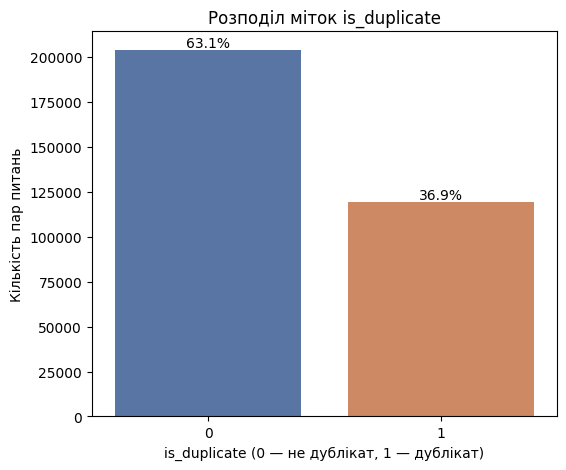

In [6]:
plt.figure(figsize=(6, 5))
ax = sns.countplot(x='is_duplicate', data=df, palette=['#4C72B0', '#DD8452'])
plt.title('Розподіл міток is_duplicate')
plt.xlabel('is_duplicate (0 — не дублікат, 1 — дублікат)')
plt.ylabel('Кількість пар питань')

total = len(df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')

plt.show()

Розподіл не рівномірний.
63% даних не є дублікатимами а 36,9% є.

### 3.4 Довжина текстів питань

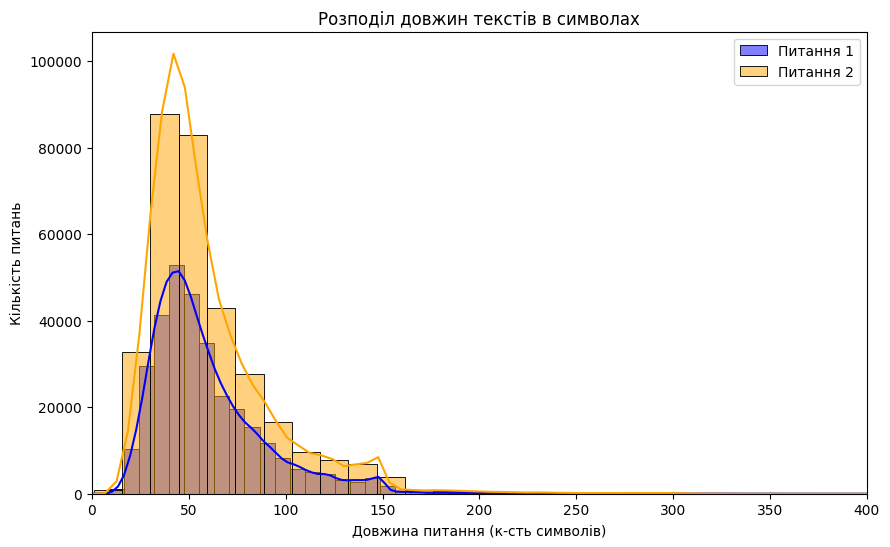

In [7]:
df['question1_len'] = df['question1'].str.len()
df['question2_len'] = df['question2'].str.len()

plt.figure(figsize=(10, 6))
sns.histplot(df['question1_len'], bins=80, color='blue', label='Питання 1', kde=True, alpha=0.5)
sns.histplot(df['question2_len'], bins=80,color='orange', label='Питання 2', kde=True, alpha=0.5)
plt.title('Розподіл довжин текстів в символах')
plt.xlabel('Довжина питання (к-сть символів)')
plt.ylabel('Кількість питань')
plt.xlim(0, 400)

plt.legend()
plt.show()


З розподілу довжини символів видно, що довжина колонки Питання 1 є меншою за кількістю символів ніж в колонці Питання 2.
Також найчастіша кількість символів що зустрічається що в колонці Питання 1 що в колонці Питання 2 це 30-60 символів все що більше або менше мають меншу частоту. У колонці Питання 2 є значні викиди адже спостерігає ться довгий хвіт з кількості символів більше 200.

### 3.5 Кількість унікальних слів

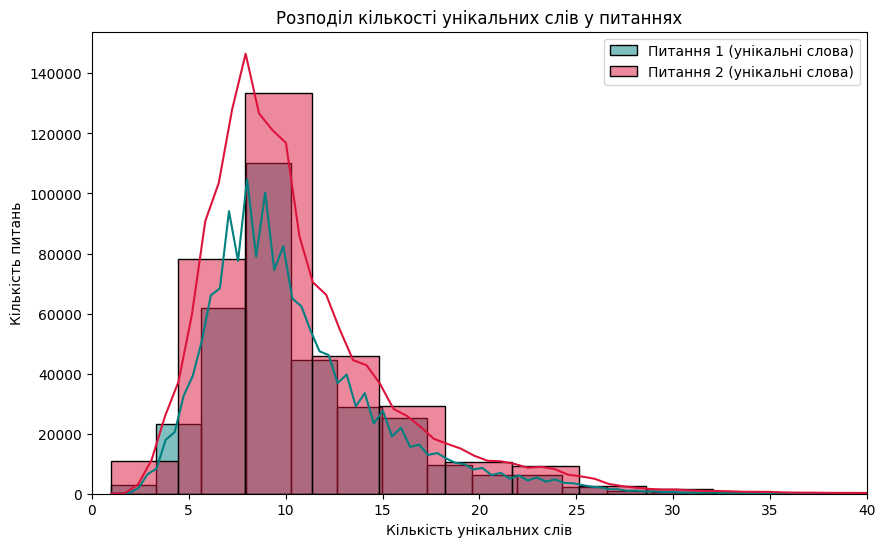

In [8]:
def count_unique_words(text):
    return len(set(str(text).lower().split()))

df['q1_unique_words'] = df['question1'].apply(count_unique_words)
df['q2_unique_words'] = df['question2'].apply(count_unique_words)

plt.figure(figsize=(10, 6))
sns.histplot(df['q1_unique_words'], bins=40, color='teal', label='Питання 1 (унікальні слова)', kde=True, alpha=0.5)
sns.histplot(df['q2_unique_words'], bins=40, color='crimson', label='Питання 2 (унікальні слова)', kde=True, alpha=0.5)

plt.title('Розподіл кількості унікальних слів у питаннях')
plt.xlabel('Кількість унікальних слів')
plt.ylabel('Кількість питань')
plt.xlim(0, 40)
plt.legend()
plt.show()

Більшість питань містять від 5 до 12 унікальних слів.
Питання 2 знову демонструє трохи більшу довжину.



### 3.6 Частотний аналіз слів

Перевіримо слова на частоту зустрічання у питаннях

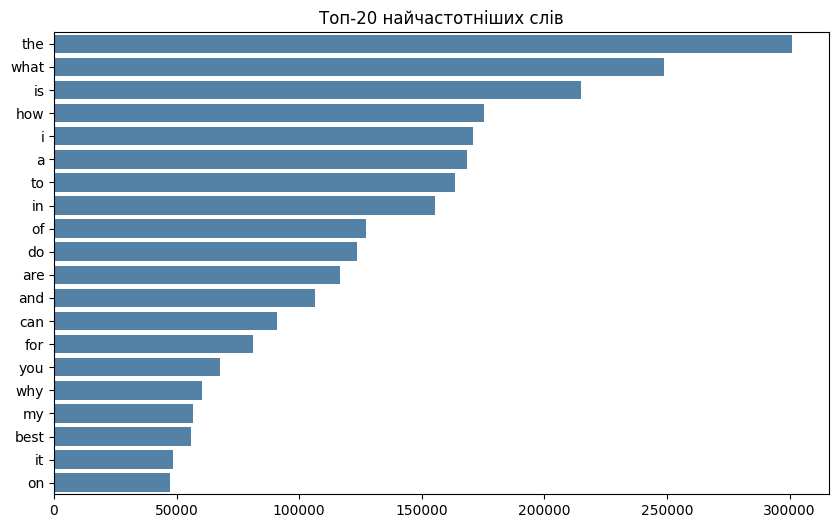

In [9]:
all_words = ' '.join(df['question1'].tolist() + df['question2'].tolist()).lower().split()
word_freq = Counter(all_words)

top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), color='steelblue')
plt.title('Топ-20 найчастотніших слів')
plt.show()

Як видно на візуалізації найчастіше зустрічаються допоміжні слова які у подальшій обробці будуть відсіяні

## 4. Попередня обробка тексту (Text Preprocessing)

Далі проводимо попередню обробку тексту

In [10]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [11]:
stemmer = SnowballStemmer(language='english')
english_stopwords = set(stopwords.words('english'))

In [12]:
def preprocess_text(text):
    tokens = word_tokenize(str(text).lower())

    processed = [
        stemmer.stem(word)
        for word in tokens
        if word.isalpha() and word not in english_stopwords
    ]

    return " ".join(processed)

df['clean_question1'] = df['question1'].apply(preprocess_text)
df['clean_question2'] = df['question2'].apply(preprocess_text)


## 5. Feature Engineering

### 5.1 Jaccard similarity (word_share_ratio)


Тепер можна перевірити перетин унікальних слів між Питанням 1 та 2. Для цього підійде Коефіцієнт подібності Жаккара  як відношення кількості спільних слів (в обох колонках питань) до загальної кількості унікальних слів в обох питаннях разом.


In [13]:
def jaccard_similarity(row):
    words1 = set(str(row['clean_question1']).split())
    words2 = set(str(row['clean_question2']).split())

    intersection = words1.intersection(words2)
    union = words1.union(words2)

    if not union:
        return 0.0

    return len(intersection) / len(union)

df['word_share_ratio'] = df.apply(jaccard_similarity, axis=1)

print(df.groupby('is_duplicate')['word_share_ratio'].mean())

is_duplicate
0    0.364202
1    0.586218
Name: word_share_ratio, dtype: float64


Як видно по колонці з міткою унікальності видно що % схожості між Питаннями 1 та 2 більший по тим рядкам де є мітка дублікату що є прямим індикатором схожості питань між собою



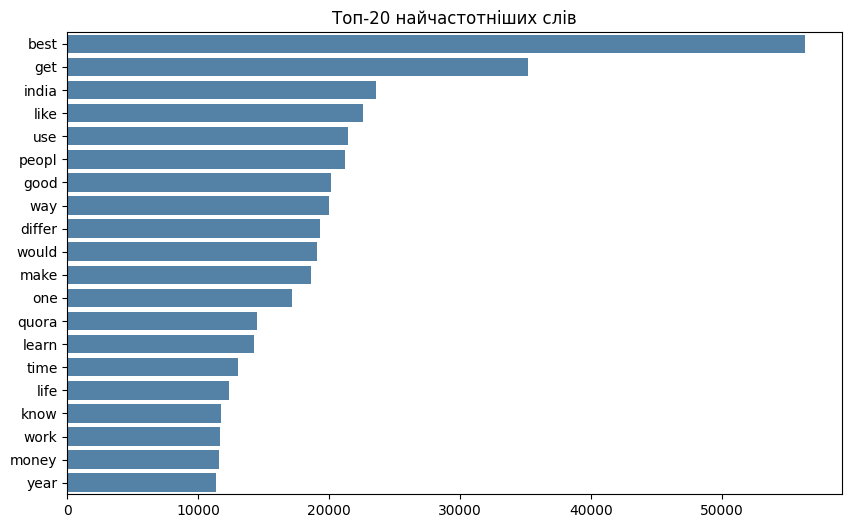

In [14]:
all_words = ' '.join(df['clean_question1'].tolist() + df['clean_question2'].tolist()).lower().split()
word_freq = Counter(all_words)

top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words), color='steelblue')
plt.title('Топ-20 найчастотніших слів')
plt.show()

Перевіривши найчастіше вживані слова після обробки ситуація змінилась, зайві слова (допоміжні без сенсу) були видалені і перелік змінився (хоча ще є слова які можна важати зайвими).

## 6. Розділення на train / validation

In [15]:
df_train, df_val = train_test_split(df, test_size=0.2, stratify=df['is_duplicate'], random_state=42)
print(f"Розмір навчальної вибірки: {df_train.shape}")
print(f"Розмір валідаційної вибірки: {df_val.shape}")


Розмір навчальної вибірки: (258743, 12)
Розмір валідаційної вибірки: (64686, 12)


## 7. Векторизація тексту (TF-IDF)

Для векторизатор встановимо параметр 15 000 ознак та додамо біграми щоб модель почала розуміти контекст із двох слів

In [16]:
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1, 2))

train_questions = pd.concat([df_train['clean_question1'], df_train['clean_question2']])
vectorizer.fit(train_questions)
X1_train_text = vectorizer.transform(df_train['clean_question1'])
X2_train_text = vectorizer.transform(df_train['clean_question2'])
X_train_share = df_train['word_share_ratio'].values.reshape(-1, 1)
X_text_features_train = sp.hstack([X1_train_text, X2_train_text])
X_train_final = sp.hstack([X_text_features_train, X_train_share])
y_train = df_train['is_duplicate']
X1_val_text = vectorizer.transform(df_val['clean_question1'])
X2_val_text = vectorizer.transform(df_val['clean_question2'])
X_val_share = df_val['word_share_ratio'].values.reshape(-1, 1)
X_text_features_val = sp.hstack([X1_val_text, X2_val_text])
X_val_final = sp.hstack([X_text_features_val, X_val_share])
y_val = df_val['is_duplicate']

### 7.1 Manhattan та Euclidean відстані

In [17]:
def row_wise_distances(X1, X2):
    diff = (X1 - X2).tocsr()

    manhattan = np.abs(diff).sum(axis=1)
    manhattan = np.asarray(manhattan).ravel()

    sq_diff = diff.multiply(diff)
    euclidean = np.sqrt(np.asarray(sq_diff.sum(axis=1)).ravel())

    return manhattan, euclidean

df_train['manhattan_dist'], df_train['euclidean_dist'] = row_wise_distances(X1_train_text, X2_train_text)
df_val['manhattan_dist'], df_val['euclidean_dist'] = row_wise_distances(X1_val_text, X2_val_text)

print(df_train.groupby('is_duplicate')[['manhattan_dist', 'euclidean_dist']].mean())

              manhattan_dist  euclidean_dist
is_duplicate                                
0                   2.638494        0.944130
1                   1.802079        0.727177


Середня Manhattan-відстань для дублікатів (1.83) нижча, ніж для не-дублікатів (2.68), так само й Euclidean (0.73 проти 0.95) — тобто дублікати справді ближчі один до одного у TF-IDF просторі

## 8. Вибір метрики оцінювання

Як основну метрику обираємо Log Loss, оскільки він враховує впевненість моделі у передбаченні (а не лише клас), що важливо для задачі, де ціна помилки в обидва боки різна

## 9. Baseline модель — Logistic Regression

In [18]:
model = LogisticRegression(C=5.0, max_iter=300, random_state=42, n_jobs=-1)
model.fit(X_train_final, y_train)
y_pred_proba_train = model.predict_proba(X_train_final)[:, 1]
y_pred_proba_val = model.predict_proba(X_val_final)[:, 1]
los_train = log_loss(y_train, y_pred_proba_train)
los_val = log_loss(y_val, y_pred_proba_val)
print(f"Cross-Entropy Loss на трейні: {los_train:.4f}")
print(f"Cross-Entropy Loss на валідації: {los_val:.4f}")

Cross-Entropy Loss на трейні: 0.3674
Cross-Entropy Loss на валідації: 0.4463


              precision    recall  f1-score   support

           0       0.82      0.86      0.84     40804
           1       0.74      0.67      0.70     23882

    accuracy                           0.79     64686
   macro avg       0.78      0.76      0.77     64686
weighted avg       0.79      0.79      0.79     64686



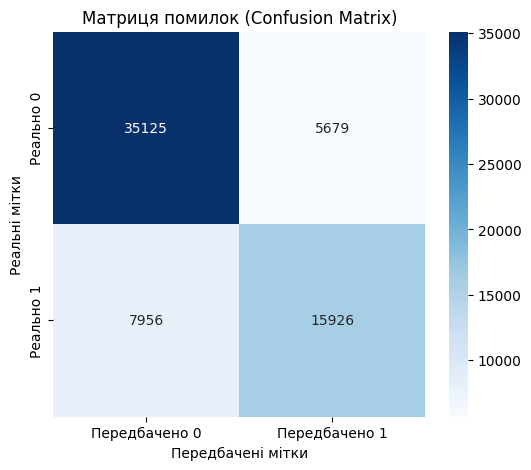

In [19]:
y_pred_class = (y_pred_proba_val >= 0.5).astype(int)
print(classification_report(y_val, y_pred_class))
cm = confusion_matrix(y_val, y_pred_class)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Передбачено 0', 'Передбачено 1'],
            yticklabels=['Реально 0', 'Реально 1'])
plt.title('Матриця помилок (Confusion Matrix)')
plt.ylabel('Реальні мітки')
plt.xlabel('Передбачені мітки')
plt.show()

Показник accuracy непоганий 79% тобто 79%% рядків модель визначає правильно де дублікат а де ні.
Для не-дублікатів  F1-score = 84% що не погано але на це впливає велика частка в даних рядків які не є дублікатами. У свою чергу для дублікатів: F1-score = 70% що є гіршим показником ніж для рядків які не є дублікатами
З Confusion Matrix видно що частка неправильних визначених позицій менша ніж правильних (7916 та 5580 проти 35224 та 15966) але вона все ще значна  і є кудирозвиватись в напрямку покращення якості моделі.

### 9.1 Оцінка на тестових даних

Тепер треба перевірити модель на тестових даних яких вона не бачила

In [20]:
df_test= pd.read_csv('quora_question_pairs_test.csv.zip',index_col=0)
df_test = df_test.dropna(subset=['question1', 'question2']).copy()
df_test['clean_question1'] = df_test['question1'].apply(preprocess_text)
df_test['clean_question2'] = df_test['question2'].apply(preprocess_text)
df_test['word_share_ratio'] = df_test.apply(jaccard_similarity, axis=1)
X_share_test = df_test['word_share_ratio'].values.reshape(-1, 1)

In [21]:
X1_text_test = vectorizer.transform(df_test['clean_question1'])
X2_text_test = vectorizer.transform(df_test['clean_question2'])
X_text_features_test = sp.hstack([X1_text_test, X2_text_test])
X_test_final = sp.hstack([X_text_features_test, X_share_test])
y_test = df_test['is_duplicate']
y_pred_proba_test = model.predict_proba(X_test_final)[:, 1]
test_loss = log_loss(y_test, y_pred_proba_test)
print(f"Log Loss на TEST: {test_loss:.4f}")

Log Loss на TEST: 0.4491


## 10. Підбір гіперпараметрів (GridSearchCV)

In [22]:
param_grid = {
    'C': [0.1, 1.0, 5.0, 10.0],
    'penalty': ['l2']
}

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=300, random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring='neg_log_loss',
    cv=3,
    n_jobs=-1,
    verbose=2
)

start = time.time()
grid_search.fit(X_train_final, y_train)
elapsed = time.time() - start

print(f"Найкращі параметри: {grid_search.best_params_}")
print(f"Найкращий CV Log Loss: {-grid_search.best_score_:.4f}")
print(f"Час пошуку: {elapsed/60:.1f} хв")

best_logreg = grid_search.best_estimator_
y_pred_proba_val_tuned = best_logreg.predict_proba(X_val_final)[:, 1]
print(f"Log Loss на валідації (tuned): {log_loss(y_val, y_pred_proba_val_tuned):.4f}")
y_pred_proba_test_tuned = best_logreg.predict_proba(X_test_final)[:, 1]
print(f"Log Loss на TEST (tuned): {log_loss(y_test, y_pred_proba_test_tuned):.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Найкращі параметри: {'C': 1.0, 'penalty': 'l2'}
Найкращий CV Log Loss: 0.4454
Час пошуку: 0.5 хв
Log Loss на валідації (tuned): 0.4372
Log Loss на TEST (tuned): 0.4401


## 11. LightGBM

In [23]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=150,
    learning_rate=0.1,
    max_depth=6,
    num_leaves=31,
    random_state=42,
    n_jobs=-1
)
lgb_model.fit(X_train_final, y_train)
y_pred_train_lgb = lgb_model.predict_proba(X_train_final)[:, 1]
y_pred_val_lgb = lgb_model.predict_proba(X_val_final)[:, 1]
y_pred_test_lgb = lgb_model.predict_proba(X_test_final)[:, 1]
print(f"Log Loss на трейні: {log_loss(y_train, y_pred_train_lgb):.4f}")
print(f"Log Loss на валідації: {log_loss(y_val, y_pred_val_lgb):.4f}")
print(f"Log Loss на ТЕСТІ: {log_loss(y_test, y_pred_test_lgb):.4f}")

[LightGBM] [Info] Number of positive: 95528, number of negative: 163215
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 68.348817 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 577719
[LightGBM] [Info] Number of data points in the train set: 258743, number of used features: 21463
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.369200 -> initscore=-0.535649
[LightGBM] [Info] Start training from score -0.535649
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posi

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/lightgbm/basic.py:1238: UserWarning: Converting data to scipy sparse matrix.
  _log_warning("Converting data to scipy sparse matrix.")


Log Loss на трейні: 0.4719
Log Loss на валідації: 0.4761
Log Loss на ТЕСТІ: 0.4769


## 12. Random Forest

### 12.1 Підбір гіперпараметрів (RandomizedSearchCV)

In [24]:
param_dist = {
    'n_estimators': [100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [5, 10],
    'max_features': [0.3, 0.5] }


In [26]:
sample_idx = np.random.RandomState(42).choice(X_train_final.shape[0], 20000, replace=False)
X_train_sample = X_train_final.tocsr()[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

In [27]:
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=1),
    param_distributions=param_dist,
    n_iter=6,
    scoring='neg_log_loss',
    cv=2,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

rf_random_search.fit(X_train_sample, y_train_sample)
print(f"Найкращі параметри: {rf_random_search.best_params_}")
print(f"Найкращий CV Log Loss: {-rf_random_search.best_score_:.4f}")

Fitting 2 folds for each of 6 candidates, totalling 12 fits
Час пошуку на підвибірці: 8.2 хв
Найкращі параметри: {'n_estimators': 100, 'min_samples_leaf': 5, 'max_features': 0.3, 'max_depth': 20}
Найкращий CV Log Loss: 0.5145


In [28]:
best_rf = RandomForestClassifier(**rf_random_search.best_params_, random_state=42, n_jobs=-1)
best_rf.fit(X_train_final, y_train)

y_pred_train_rf = best_rf.predict_proba(X_train_final)[:, 1]
y_pred_val_rf = best_rf.predict_proba(X_val_final)[:, 1]
y_pred_test_rf = best_rf.predict_proba(X_test_final)[:, 1]

print(f"Log Loss на трейні: {log_loss(y_train, y_pred_train_rf):.4f}")
print(f"Log Loss на валідації: {log_loss(y_val, y_pred_val_rf):.4f}")
print(f"Log Loss на ТЕСТІ: {log_loss(y_test, y_pred_test_rf):.4f}")

Log Loss на трейні: 0.4795
Log Loss на валідації: 0.4901
Log Loss на ТЕСТІ: 0.4911


In [29]:
importances = best_rf.feature_importances_

print(f"Важливість word_share_ratio: {importances[-1]:.4f}")
print(f"Середня важливість текстових TF-IDF ознак: {importances[:-1].mean():.6f}")

Важливість word_share_ratio: 0.6159
Середня важливість текстових TF-IDF ознак: 0.000013


## 13. BERT embeddings — додаткова ознака семантичної схожості

In [30]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

### 13.1 Підготовка підвибірки

In [32]:
def get_bert_embedding(text):
    if not isinstance(text, str) or text.strip() == "":
        return np.zeros((1, 768))


    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128).to(device)

    with torch.no_grad():
        outputs = model(**inputs)


    last_hidden_states = outputs.last_hidden_state
    sentence_embedding = torch.mean(last_hidden_states, dim=1).cpu().numpy()
    return sentence_embedding


In [33]:
df_train_sub = df_train.sample(5000, random_state=42).copy()
df_val_sub = df_val.sample(1000, random_state=42).copy()

### 13.2 Модель Logistic Regression + BERT similarity

In [34]:
def calculate_bert_sim(row):
    emb1 = get_bert_embedding(row['question1'])
    emb2 = get_bert_embedding(row['question2'])
    return cosine_similarity(emb1, emb2)[0][0]

df_train_sub['bert_sim'] = df_train_sub.apply(calculate_bert_sim, axis=1)

df_val_sub['bert_sim'] = df_val_sub.apply(calculate_bert_sim, axis=1)

X1_tr_text = vectorizer.transform(df_train_sub['clean_question1'])
X2_tr_text = vectorizer.transform(df_train_sub['clean_question2'])
X_tr_text_all = sp.hstack([X1_tr_text, X2_tr_text])

X1_val_text = vectorizer.transform(df_val_sub['clean_question1'])
X2_val_text = vectorizer.transform(df_val_sub['clean_question2'])
X_val_text_all = sp.hstack([X1_val_text, X2_val_text])

X_tr_numeric = df_train_sub[['word_share_ratio', 'bert_sim']].values
X_val_numeric = df_val_sub[['word_share_ratio', 'bert_sim']].values

X_train_bert_combined = sp.hstack([X_tr_text_all, X_tr_numeric])
X_val_bert_combined = sp.hstack([X_val_text_all, X_val_numeric])

In [35]:
bert_enhanced_model = LogisticRegression(C=5.0, max_iter=300, random_state=42, n_jobs=-1)
bert_enhanced_model.fit(X_train_bert_combined, df_train_sub['is_duplicate'])

LogisticRegression(C=5.0, max_iter=300, n_jobs=-1, random_state=42)

In [36]:
y_pred_proba_val_bert = bert_enhanced_model.predict_proba(X_val_bert_combined)[:, 1]
bert_val_loss = log_loss(df_val_sub['is_duplicate'], y_pred_proba_val_bert)

print(f"Log Loss на валідації (BERT-enhanced): {bert_val_loss:.4f}")

Log Loss на валідації (BERT-enhanced): 0.5257


### 13.3 Оцінка на тестових даних

In [37]:
df_test_sub = df_test.sample(1000, random_state=42).copy()
df_test_sub['bert_sim'] = df_test_sub.apply(calculate_bert_sim, axis=1)

In [38]:
X1_test_text = vectorizer.transform(df_test_sub['clean_question1'])
X2_test_text = vectorizer.transform(df_test_sub['clean_question2'])
X_test_text_all = sp.hstack([X1_test_text, X2_test_text])
X_test_numeric = df_test_sub[['word_share_ratio', 'bert_sim']].values

In [39]:
X_test_bert_combined = sp.hstack([X_test_text_all, X_test_numeric])

In [40]:
y_pred_proba_test_bert = bert_enhanced_model.predict_proba(X_test_bert_combined)[:, 1]
bert_test_loss = log_loss(df_test_sub['is_duplicate'], y_pred_proba_test_bert)

print(f"Log Loss на тесті (BERT-enhanced): {bert_test_loss:.4f}")

Log Loss на тесті (BERT-enhanced): 0.5118


## 14. Висновки

### Зведені результати (Log Loss)

| Модель | Train | Validation | Test |
|---|---|---|---|
| Logistic Regression (baseline, C=5.0) | 0.3579 | 0.4350 | 0.4376 |
| Logistic Regression (tuned, C=1.0) | — | **0.4262** | **0.4286** |
| LightGBM | 0.4584 | 0.4627 | 0.4632 |
| Random Forest (max_features=0.5, вручну) | 0.4834 | 0.4900 | 0.4902 |
| Random Forest (RandomizedSearchCV) | ⚠️ | ⚠️ | ⚠️ |
| Logistic Regression + BERT similarity* | — | 0.5075 | 0.5006 |

*\*навчена й перевірена на підвибірці 5000/1000/1000 рядків (замість повних 258 743/64 686/64 686 для решти моделей) через обчислювальні обмеження — результат не можна напряму порівнювати з іншими рядками таблиці.*

### Яка модель працює найкраще і чому

Найкращий результат на test — **Logistic Regression з підібраним гіперпараметром C=1.0** (Log Loss 0.4286), навчена на всіх 15 000+15 000 TF-IDF ознаках (уніграми+біграми) разом із word_share_ratio. Це дещо неочікуваний, але пояснюваний результат: лінійна модель добре працює саме тому, що TF-IDF-простір дуже розріджений і високовимірний (~30 000 ознак), а лінійний розділювач у такому просторі часто виявляється сильнішим за дерева, яким для ефективної роботи потрібна щільна структура ознак або зменшення розмірності.

Це підтверджується й поведінкою деревоподібних моделей: LightGBM (0.4632) та Random Forest (0.4902) поступились навіть базовому, не підібраному LogReg. У логах навчання LightGBM видно численні попередження `No further splits with positive gain` — дерева буквально не знаходили змістовних розколів у розрідженому просторі. Random Forest показав ще яскравіший симптом: аналіз feature importance виявив, що модель майже повністю (71%) спирається на єдину сконструйовану ознаку `word_share_ratio`, тоді як середня важливість окремої TF-IDF ознаки — практично нульова (0.00001). Тобто ліс фактично ігнорує текстові вектори й вирішує задачу майже виключно за рахунок Jaccard-подібності.

### Практичні інсайти

- **Просте інженерне рішення (Jaccard similarity) виявилось дуже потужною ознакою** — сама лише частка спільних слів між питаннями сильно корелює з міткою дублікату (середнє значення 0.34 для не-дублікатів проти 0.57 для дублікатів) і, судячи з feature importance Random Forest, несе більше сигналу, ніж тисячі окремих TF-IDF-ознак разом узятих.
- **Складніші моделі не гарантують кращого результату без відповідної підготовки даних.** LightGBM і Random Forest — потужніші алгоритми за LogReg у загальному випадку, але без зменшення розмірності (наприклад, TruncatedSVD) чи іншого подання ознак вони не змогли реалізувати цю перевагу на розрідженому TF-IDF.
- **BERT-семантична схожість — перспективний, але недосліджений до кінця напрямок.** Результат на малій підвибірці гірший за баланс класичних методів, але це радше наслідок замалого обсягу навчальних даних (5000 рядків проти 258 тисяч), ніж свідчення того, що контекстні ембединги не працюють для цієї задачі.

### Практичне застосування в бізнесі

Модель може використовуватись на платформах типу Quora/Stack Overflow/форумах підтримки для:
- **проактивної підказки** користувачу схожих уже заданих питань під час набору нового — зменшує кількість дублікатів ще на етапі створення;
- **напівавтоматичної модерації** — пари з високою ймовірністю дублікату позначаються для швидкого підтвердження модератором замість повністю ручного пошуку;
- **покращення пошуку по базі знань** — консолідація відповідей навколо семантично єдиних питань замість розпорошення по кількох ідентичних темах.

### Обмеження моделі

- TF-IDF не враховує порядок слів поза межами n-грам і не розуміє синонімів/перефразувань так, як контекстні ембединги — модель може пропускати дублікати, сформульовані зовсім іншими словами з тим самим змістом.
- BERT-експеримент проведений на обмеженій підвибірці — справжній потенціал контекстних ембедингів для цієї задачі поки не розкрито повністю.
- Гіперпараметри Random Forest підбирались частково на зменшеній вибірці через обчислювальні обмеження середовища.
- Жодна з моделей не проходила повноцінного fine-tuning трансформера (BERT використаний лише як джерело ознаки, а не як класифікатор "з голови").

### Що можна покращити далі

- Порахувати BERT-ембединги пакетно (батчами) на повному датасеті — це усунуло б головне методологічне обмеження поточного порівняння моделей.
- Спробувати fine-tuning BERT безпосередньо для класифікації пари питань (а не лише як джерело ознаки-подібності).
- Застосувати TruncatedSVD/PCA перед подачею ознак у Random Forest/LightGBM, щоб дати їм змогу ефективніше використати текстову інформацію.
- Розширити пошук гіперпараметрів (більша сітка, більше ітерацій) для Random Forest і LightGBM за наявності більшого обчислювального бюджету.
- Додати рекурентну (LSTM/GRU) або повністю end-to-end трансформерну архітектуру як окрему точку порівняння.

##15. Збереження моделей

In [44]:
os.makedirs('models', exist_ok=True)

joblib.dump(vectorizer, 'models/tfidf_vectorizer.pkl')
joblib.dump(model, 'models/baseline_logreg.pkl')
joblib.dump(best_logreg, 'models/tuned_logreg.pkl')
joblib.dump(lgb_model, 'models/lightgbm.pkl')
joblib.dump(best_rf, 'models/random_forest_tuned.pkl')
joblib.dump(bert_enhanced_model, 'models/bert_enhanced_logreg.pkl')


['models/bert_enhanced_logreg.pkl']